# Temporal Fusion Transformer: Bangkok PM2.5, 24 hours ahead

Runs locally on CPU in `.venv-tft` (PyTorch 2.3.1, the last build that runs on this laptop's pre-AVX2 CPU, + pytorch-forecasting). A full run takes a few hours here; on Colab with a GPU it takes minutes. Same forecast setup, split and test rows as `model.ipynb`:
- at forecast time *t*, predict *t*+1 to *t*+24; only *t*+24 is scored
- **encoder** (past 168 h, known up to *t*): PM2.5, the 2 selected fire features, weather, calendar
- **decoder** (*t*+1 to *t*+24): only inputs known in advance: archived weather forecasts and calendar
- tune on 2022 with validation Jan to Jun 2023, retrain on 2022 to 2023, test on 2024
- scored on measured hours only, against the rows every other model is scored on

Environment switches: `SMOKE=1` for a quick check that everything runs; `TFT_LOAD=1` to skip training and use the saved weights in `data/clean/tft.pt` (for example, weights trained on Colab).

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping
from pathlib import Path
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

SMOKE = os.environ.get("SMOKE") == "1"
LOAD = os.environ.get("TFT_LOAD") == "1"  # use saved weights in data/clean/tft.pt instead of training
CLEAN, FIG = Path("data/clean"), Path("figures")
TZ = "Asia/Bangkok"
H, ENCODER = 24, 168
UNHEALTHY = 37.5
torch.set_num_threads(os.cpu_count())
pl.seed_everything(42)
print("loading saved weights" if LOAD else "smoke test" if SMOKE else "full run", "| threads:", torch.get_num_threads())

Seed set to 42


loading saved weights | threads: 4


## 1. Data
TFT reads the hourly series directly. Long gaps (all stations down, or over 72 h) are dropped; `allow_missing_timesteps` lets windows span them.

In [2]:
hourly = pd.read_csv(CLEAN / "hourly.csv")
hourly["time"] = pd.to_datetime(hourly["time"], utc=True).dt.tz_convert(TZ)
START = hourly["time"].min()
hourly["time_idx"] = ((hourly["time"] - START) / pd.Timedelta(hours=1)).astype(int)

hourly["hour_sin"] = np.sin(2 * np.pi * hourly.time.dt.hour / 24)
hourly["hour_cos"] = np.cos(2 * np.pi * hourly.time.dt.hour / 24)
hourly["month_sin"] = np.sin(2 * np.pi * hourly.time.dt.month / 12)
hourly["month_cos"] = np.cos(2 * np.pi * hourly.time.dt.month / 12)
hourly["dow"] = hourly.time.dt.dayofweek.astype(float)
hourly["burning"] = hourly.time.dt.month.isin([1, 2, 3, 4]).astype(float)

KNOWN = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "precipitation", "wind_sin", "wind_cos",
         "hour_sin", "hour_cos", "month_sin", "month_cos", "dow", "burning"]
UNKNOWN = ["pm25", "fire_upwind_48h", "fire_n_r100_300_72h"]

df = hourly.dropna(subset=KNOWN + UNKNOWN)[["station", "time", "time_idx", *KNOWN, *UNKNOWN]].copy()
idx_of = lambda ts: int((pd.Timestamp(ts, tz=TZ) - START) / pd.Timedelta(hours=1))
print(f"{len(df):,} of {len(hourly):,} station-hours usable")

72,842 of 78,912 station-hours usable


/tmp/ipykernel_101146/2421800294.py:4: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  hourly["time_idx"] = ((hourly["time"] - START) / pd.Timedelta(hours=1)).astype(int)


## 2. Datasets

In [3]:
params = dict(
    time_idx="time_idx", target="pm25", group_ids=["station"],
    max_encoder_length=ENCODER, max_prediction_length=H,
    static_categoricals=["station"],
    time_varying_known_reals=KNOWN, time_varying_unknown_reals=UNKNOWN,
    target_normalizer=GroupNormalizer(groups=["station"], transformation="softplus"),
    allow_missing_timesteps=True, add_relative_time_idx=True, add_target_scales=True,
)
train_ds = TimeSeriesDataSet(df[df.time < "2023-01-01"], **params)
valid_ds = TimeSeriesDataSet.from_dataset(train_ds, df[df.time < "2023-07-01"],
                                          min_prediction_idx=idx_of("2023-01-01"), stop_randomization=True)
full_ds = TimeSeriesDataSet.from_dataset(train_ds, df[df.time < "2024-01-01"])
# first decoder step 23 h before 2024 so the t+24 targets start at 2024-01-01 00:00
test_ds = TimeSeriesDataSet.from_dataset(train_ds, df, min_prediction_idx=idx_of("2024-01-01") - (H - 1),
                                         stop_randomization=True)

BATCH = 128
loaders = {name: ds.to_dataloader(train=name in ("train", "full"), batch_size=BATCH, num_workers=0)
           for name, ds in [("train", train_ds), ("valid", valid_ds), ("full", full_ds), ("test", test_ds)]}
print({name: len(ds) for name, ds in [("train", train_ds), ("valid", valid_ds), ("full", full_ds), ("test", test_ds)]})

/tmp/ipykernel_101146/2421800294.py:18: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  idx_of = lambda ts: int((pd.Timestamp(ts, tz=TZ) - START) / pd.Timedelta(hours=1))


{'train': 23407, 'valid': 7932, 'full': 44250, 'test': 24637}


/tmp/ipykernel_101146/2421800294.py:18: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  idx_of = lambda ts: int((pd.Timestamp(ts, tz=TZ) - START) / pd.Timedelta(hours=1))


## 3. Train
Stage 1 picks the number of epochs by early stopping on validation. Stage 2 retrains from scratch on 2022 to 2023 for that many epochs, matching the LightGBM procedure.

In [4]:
def make_model():
    return TemporalFusionTransformer.from_dataset(
        train_ds, hidden_size=32, attention_head_size=2, dropout=0.1, hidden_continuous_size=16,
        learning_rate=1e-3, loss=QuantileLoss(), reduce_on_plateau_patience=2, log_interval=-1)

limits = dict(limit_train_batches=5, limit_val_batches=3, max_epochs=1) if SMOKE else \
         dict(limit_train_batches=200, max_epochs=10)
trainer_kw = dict(accelerator="auto", gradient_clip_val=0.1, enable_model_summary=False, logger=False,
                  enable_checkpointing=False, **limits)

if not LOAD:
    stage1 = pl.Trainer(callbacks=[EarlyStopping("val_loss", patience=2, mode="min")], **trainer_kw)
    model = make_model()
    print(f"{sum(p.numel() for p in model.parameters()):,} parameters")
    stage1.fit(model, loaders["train"], loaders["valid"])
    best_epochs = max(1, stage1.current_epoch - (0 if SMOKE else stage1.callbacks[0].wait_count))
    print("epochs chosen:", best_epochs)

In [5]:
model = make_model()
if LOAD:
    model.load_state_dict(torch.load(CLEAN / "tft.pt", map_location="cpu"))
    print("loaded", CLEAN / "tft.pt")
else:
    trainer_kw["max_epochs"] = best_epochs
    pl.Trainer(**trainer_kw).fit(model, loaders["full"])

/home/puyawapun/datamine/.venv-tft/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/puyawapun/datamine/.venv-tft/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


loaded data/clean/tft.pt


## 4. Predict 2024
Median (q50) is the point forecast. q90 is kept too: a warning on q90 catches peaks the median smooths over.

In [6]:
pred = model.predict(loaders["test"], mode="quantiles", return_index=True, trainer_kwargs=dict(accelerator="auto", logger=False))
q = pred.output.cpu().numpy()  # windows x 24 steps x 7 quantiles
idx = pred.index.reset_index(drop=True)
target_idx = idx["time_idx"] + (H - 1)
tft = pd.DataFrame({
    "station": idx["station"].astype(str),
    "target_time": START + pd.to_timedelta(target_idx, unit="h"),
    "pred_tft": q[:, H - 1, 3],
    "tft_q90": q[:, H - 1, 5],
})
tft = tft[tft.target_time.dt.year == 2024]
print(f"{len(tft):,} TFT forecasts for 2024")

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


/home/puyawapun/datamine/.venv-tft/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


24,637 TFT forecasts for 2024


## 5. Score against the other models
Same rows as `model.ipynb`: measured PM2.5 at *t*+24 and a forecast from every model.

In [7]:
preds = pd.read_csv(CLEAN / "test_predictions.csv")
preds["target_time"] = pd.to_datetime(preds["target_time"], utc=True).dt.tz_convert(TZ)
preds = preds.drop(columns=[c for c in ("pred_tft", "tft_q90") if c in preds]).merge(tft, on=["station", "target_time"], how="left")
PRED = [c for c in preds.columns if c.startswith("pred_")]
scored = preds.dropna(subset=PRED).copy()
print(f"{len(scored):,} rows scored by every model including TFT")

burning = scored.target_time.dt.month <= 4
mae = lambda d: {p.removeprefix("pred_"): (d[p] - d.y).abs().mean() for p in PRED}
pd.DataFrame({"MAE all 2024": mae(scored), "MAE burning season": mae(scored[burning]),
              "MAE rest of year": mae(scored[~burning])}).round(2).sort_values("MAE all 2024")

21,010 rows scored by every model including TFT


,MAE all 2024,MAE burning season,MAE rest of year
lgb + fire,5.02,6.46,4.09
lgb observed weather (leaky),5.04,6.52,4.09
lgb + weather,5.21,6.76,4.22
tft,5.29,6.80,4.32
"lgb + fire (all 39, overfits)",5.47,7.21,4.35
sarima,5.68,7.43,4.57
lgb PM2.5 only,5.68,7.74,4.36
persistence,5.92,7.62,4.83
cams,12.95,14.62,11.87


In [8]:
scored["date"] = scored.target_time.dt.date
cols = PRED + ["tft_q90"]
daily = scored.groupby(["station", "date"]).agg(n=("y", "size"), y=("y", "mean"), **{c: (c, "mean") for c in cols})
daily = daily[daily.n >= 18]
actual = daily.y > UNHEALTHY

def f1(p):
    hit = p > UNHEALTHY
    tp = (hit & actual).sum()
    precision, recall = tp / max(hit.sum(), 1), tp / max(actual.sum(), 1)
    return {"precision": precision, "recall": recall, "F1": 2 * precision * recall / max(precision + recall, 1e-9)}

pd.DataFrame({c.removeprefix("pred_"): f1(daily[c]) for c in cols}).T.round(2)

,precision,recall,F1
persistence,0.75,0.74,0.75
cams,0.49,0.59,0.53
sarima,0.84,0.66,0.73
lgb PM2.5 only,0.79,0.55,0.65
lgb + weather,0.90,0.61,0.73
lgb + fire,0.88,0.68,0.77
"lgb + fire (all 39, overfits)",0.94,0.50,0.65
lgb observed weather (leaky),0.87,0.66,0.75
tft,0.94,0.53,0.68
tft_q90,0.69,0.84,0.76


## 6. What TFT pays attention to

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


/home/puyawapun/datamine/.venv-tft/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


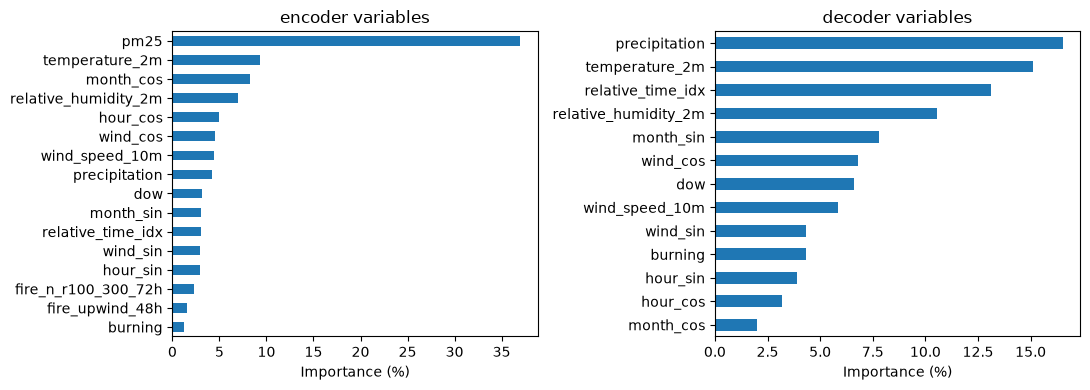

In [9]:
# one window per station per day keeps memory low on a 3 GB machine
daily_ds = test_ds.filter(lambda idx: idx.time_idx_first_prediction % 24 == 0)
raw = model.predict(daily_ds.to_dataloader(train=False, batch_size=BATCH, num_workers=0), mode="raw",
                    trainer_kwargs=dict(accelerator="auto", logger=False))
interp = model.interpret_output(raw.output if hasattr(raw, "output") else raw, reduction="sum")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, key, names in [(axes[0], "encoder_variables", model.encoder_variables),
                       (axes[1], "decoder_variables", model.decoder_variables)]:
    imp = pd.Series(interp[key].cpu().numpy(), index=names)
    (imp / imp.sum() * 100).sort_values().plot.barh(ax=ax)
    ax.set(xlabel="Importance (%)", title=key.replace("_", " "))
plt.tight_layout()
plt.savefig(FIG / "tft_variable_importance.png", dpi=150)
plt.show()

In [10]:
if not SMOKE:
    preds.to_csv(CLEAN / "test_predictions.csv", index=False)
    if not LOAD:
        torch.save(model.state_dict(), CLEAN / "tft.pt")
    print("saved pred_tft and tft_q90 into test_predictions.csv")

saved pred_tft and tft_q90 into test_predictions.csv
